# Assignment 4: API & Webinterface

## Wo befinden wir uns im MLOps-Projekt?

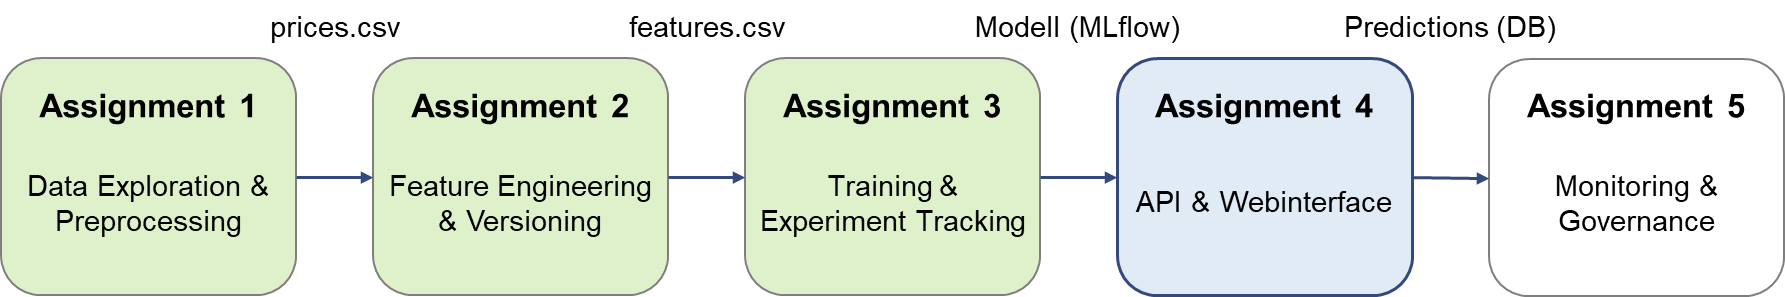

## Was passiert in diesem Notebook?

Sie bauen eine **FastAPI-Anwendung**, die Kraftstoffpreis-Vorhersagen bereitstellt und im Browser bedienbar ist. Das trainierte Modell aus A3 wird über die MLflow Model Registry geladen. Jede Vorhersage wird in der PostgreSQL-Datenbank geloggt und bietet somit die Grundlage für den Feedback Loop in A5.

**Voraussetzung:** A3 abgeschlossen (Modell in MLflow Registry registriert)  
**Ausgabe:** Laufende FastAPI-App + Vorhersagen in der `predictions`-Tabelle  

---

**Aufgaben in diesem Notebook:**
| Aufgabe | Datei | Beschreibung |
|---|---|---|
| Predictor implementieren | `src/predict.py` | Modell aus Registry laden, Features berechnen, Vorhersage zurückgeben |
| POST `/predict` Endpoint | `app/main.py` | Vorhersage berechnen + in DB loggen |
| GET `/` Web-Frontend | `app/main.py` | HTML-Formular im Browser |

## Bewertungskriterien (12 Punkte)

| Kriterium | Punkte |
|---|---|
| Web-Frontend: Formular, fetch-Request, Ergebnis anzeigen, Fehlerbehandlung | 8 |
| Ansprechendes Design & Prompt-Engineering-Dokumentation (Methode + Prompt-Historie) | 4 |
| **Gesamt** | **12** |

**Abgabe: 04.06.2026 um 23:59 Uhr**


## Architektur-Übersicht

```
Browser / API-Client
       │
       │ POST /predict {"predict_for": "2026-06-01T14:00:00"}
       ▼
┌─────────────────────────────────┐
│ FastAPI App (app/main.py)       │
│                                 │
│  /predict (POST)                │
│    ├── get_predictor()          │─────▶ MLflow Registry
│    │      └── load_model()      │       (bestes Modell abrufen)
│    ├── features.csv lesen       │
│    ├── Vorhersage berechnen     │
│    ├── In DB loggen             │─────▶ PostgreSQL
│    └── PredictResponse          │       predictions-Tabelle
│                                 │
│  / (GET)                        │
│    └── HTML-Formular            │─────▶ Browser
└─────────────────────────────────┘
```

**Datenbankstruktur (bereits angelegt durch A0_Setup.ipynb):**
```sql
"{GROUP_ID}".predictions:
  id              SERIAL PRIMARY KEY
  prediction_ts   TIMESTAMPTZ   -- Zeitstempel der Vorhersage
  predicted_price FLOAT         -- Vorhergesagter Kraftstoffpreis (EUR/L)
  actual_price    FLOAT         -- Tatsächlicher Preis (wird später befüllt durch A5)
  model_version   VARCHAR       -- MLflow Modellversion
```

In [ ]:
import os, sys

_cwd = os.getcwd()
PROJECT_ROOT = _cwd if os.path.exists(os.path.join(_cwd, "config.py")) \
               else os.path.abspath(os.path.join(_cwd, ".."))
sys.path.insert(0, PROJECT_ROOT)

from config import GROUP_ID, STATION_ID, MLFLOW_TRACKING_URI, DEFAULT_PARAMS, FUEL_TYPE

params        = DEFAULT_PARAMS
features_path = os.path.join(PROJECT_ROOT, params["paths"]["processed"])
predict_src   = os.path.join(PROJECT_ROOT, "src", "predict.py")
main_py       = os.path.join(PROJECT_ROOT, "app", "main.py")

print(f"Gruppe         : {GROUP_ID}")
print(f"Station        : {STATION_ID}")
print(f"Kraftstoffsorte: {FUEL_TYPE}")
print(f"MLflow URI     : {MLFLOW_TRACKING_URI}")
print(f"Features Pfad  : {features_path}")
print(f"Modell-Name    : {params['mlflow']['model_name']}")

---
## `src/predict.py` – Predictor (vorgegeben)

`src/predict.py` ist vollständig vorgegeben und muss **nicht** verändert werden.
Verstehen Sie, wie das Modul aufgebaut ist – Sie werden es in A5 wieder sehen.

### Klasse `FuelPricePredictor`

Die Klasse implementiert zwei Methoden:

**`load_model()`** – Modell aus MLflow Registry laden:
```python
# Neueste Version aus der Registry bestimmen
versions = client.search_model_versions(f"name='{model_name}'")
latest = max(versions, key=lambda v: int(v.version))
self._model = mlflow.sklearn.load_model(f"models:/{model_name}/{latest.version}")

# Feature-Reihenfolge aus features.csv lesen
cols = pd.read_csv(features_path, nrows=0).columns.tolist()
self._feature_cols = [c for c in cols if c not in _EXCLUDE_COLS and c != target]
```

**`predict()`** – Vorhersage berechnen:
```python
# 1. Stündliche Preise aus DB laden (bereits vorgegeben)
hourly = _fetch_hourly_prices(station_id, predict_for, hours=172)

# 2. Dieselben Features wie in A2 create_features() aufbauen
features_dict = {
    "hour": predict_for.hour,
    "price_lag_1": _get_price_at(hourly, predict_for - timedelta(hours=1)),
    "price_ma_24": ...,    # Mittelwert der letzten 24h aus hourly
    ...                    # alle 10 Features wie in A2
}

# 3. Vorhersage und DB-Logging
X = np.array(feature_values).reshape(1, -1)
predicted_price = float(self._model.predict(X)[0])
# INSERT INTO predictions ...
```

> **Zusammenhang A2 → A4:** Die Feature-Namen in `features_dict` müssen exakt mit
> den Spaltennamen aus Ihrer `features.csv` übereinstimmen – deshalb hat A2 die
> Features exakt vorgeschrieben. `predict.py` liest die Spaltenreihenfolge aus
> `features.csv` und baut den Feature-Vektor in derselben Reihenfolge auf.


In [ ]:
# src/predict.py testen – Modell laden und eine Vorhersage durchführen
import importlib
import src.predict as predict_module
importlib.reload(predict_module)
from src.predict import get_predictor
from datetime import datetime, timezone

predictor = get_predictor()
predictor.load_model()
print(f"Modell geladen: v{predictor._model_version}")
print(f"Feature-Spalten ({len(predictor._feature_cols)}): {predictor._feature_cols}")

price, version, _ = predictor.predict(
    predict_for=datetime(2026, 1, 15, 14, 0, tzinfo=timezone.utc),
    station_id=STATION_ID
)
print(f"Vorhersage: {price:.4f} EUR/L (Modell v{version})")


---
## `app/main.py` – FastAPI-Anwendung (vorgegeben)

`app/main.py` ist vollständig implementiert und muss **nicht** verändert werden.
Verstehen Sie, wie die einzelnen Teile zusammenspielen:

### Lifespan: Modell beim Start laden

FastAPI führt beim Start den `lifespan`-Block aus. Dort wird `predictor.load_model()` aufgerufen
– Ihr Modell aus der MLflow Registry steht dann für alle Requests bereit.

```python
@asynccontextmanager
async def lifespan(app: FastAPI):
    predictor = get_predictor()
    predictor.load_model()          # ← Ihr TODO aus src/predict.py
    app.state.predictor = predictor
    yield
```

### Pydantic-Schemas

FastAPI validiert Requests und Responses automatisch anhand dieser Modelle:

```python
class PredictRequest(BaseModel):
    predict_for: str   # ISO-8601, z.B. "2026-06-01T14:00:00"
    station_id:  str   # UUID der Tankstelle

class PredictResponse(BaseModel):
    predicted_price: float   # Vorhergesagter Preis in EUR/L
    model_version:   str     # MLflow-Modellversion
    prediction_for:  str     # Echo des Zeitstempels
    station_id:      str     # Echo der Station
```

### POST `/predict` Endpoint

Der Endpoint ruft `predictor.predict()` auf – also Ihre Implementierung aus `src/predict.py`:

```python
@app.post("/predict", response_model=PredictResponse)
def predict(request: PredictRequest):
    predict_for = datetime.fromisoformat(request.predict_for)
    predicted_price, model_version, confidence = predictor.predict(
        predict_for=predict_for,
        station_id=request.station_id,
    )
    return PredictResponse(predicted_price=round(predicted_price, 4), ...)
```

> **Fazit:** Die API verbindet Ihre `src/predict.py`-Implementierung mit der Außenwelt.
> Sobald `load_model()` und `predict()` korrekt implementiert sind, funktioniert die API.

In [ ]:
# app/main.py anzeigen
with open(os.path.join(PROJECT_ROOT, "app", "main.py"), encoding="utf-8") as f:
    print(f.read())

---
## TODO (1/1): Web-Frontend (`app/static/index.html`)

### Wo liegt die HTML-Datei?

Das Frontend besteht aus einer **separaten HTML-Datei**: `app/static/index.html`.

Der `GET /` Endpoint in `app/main.py` liefert diese Datei aus – das ist bereits implementiert:

```python
_STATIC_DIR = os.path.join(os.path.dirname(__file__), "static")

@app.get("/", response_class=FileResponse)
def index():
    return FileResponse(os.path.join(_STATIC_DIR, "index.html"))
```

**Ihre Aufgabe:** Implementieren Sie `app/static/index.html`. Diese Datei enthält das gesamte HTML, CSS und JavaScript des Frontends.

---

### Generative KI erlaubt!

Sie dürfen generative KI-Werkzeuge (z. B. ChatGPT, Claude, GitHub Copilot) verwenden, um das HTML-Frontend zu gestalten und zu stylen.

**Wichtig:** Sie müssen dabei Methoden des Prompt Engineerings anwenden, wie Sie sie in der Vorlesung gelernt haben (z. B. Role Prompting, Few-Shot Prompting, Chain-of-Thought, Persona etc.).

**Pflichtabgabe:** Reichen Sie Ihre vollständige **Prompt-Historie** (alle Prompts und KI-Antworten) als Screenshot oder Textexport zusammen mit dem Code ein. Die Prompt-Historie ist Teil der Bewertung!

---

### Mindestkriterien für das Frontend

Ihr `app/static/index.html` muss mindestens folgende Anforderungen erfüllen:

| Kriterium | Beschreibung |
|---|---|
| **Titel & Branding** | Seitentitel mit Ihrem Kraftstofftyp (`FUEL_TYPE`) und Ihrer Gruppen-ID |
| **Eingabeformular** | Eingabefeld für `predict_for` (ISO-8601 Zeitstempel, z. B. `2026-06-01T14:00:00`) |
| **Vorhersage auslösen** | JavaScript sendet einen `fetch`-POST-Request an `/predict` |
| **Ergebnis anzeigen** | Vorhergesagter Preis (`predicted_price`) und Modellversion (`model_version`) werden angezeigt |
| **Fehlerbehandlung** | Bei HTTP-Fehler (4xx/5xx) wird eine lesbare Fehlermeldung angezeigt |
| **Styling** | Die Seite ist ansprechend gestaltet (z. B. mit Bootstrap CDN oder eigenem CSS) |

---

### Technische Hinweise

- **JavaScript Fetch**: Der POST-Request sendet JSON (`Content-Type: application/json`):
  ```javascript
  const response = await fetch('/predict', {
      method: 'POST',
      headers: {'Content-Type': 'application/json'},
      body: JSON.stringify({predict_for: timestamp})
  });
  const data = await response.json();
  ```
- **Ergebnis-JSON** (`PredictResponse`):
  ```json
  {
    "predicted_price": 1.739,
    "model_version": "1",
    "prediction_for": "2026-06-01T14:00:00",
    "station_id": "..."
  }
  ```
- **Bootstrap CDN** für schnelles Styling: `<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5/dist/css/bootstrap.min.css">`

**Dokumentation:**
- [Fetch API (MDN)](https://developer.mozilla.org/en-US/docs/Web/API/Fetch_API/Using_Fetch)
- [Bootstrap 5](https://getbootstrap.com/docs/5.0/getting-started/introduction/)


In [ ]:
## TODO (1/1): app/static/index.html implementieren

# Öffnen Sie die Datei app/static/index.html und implementieren Sie das Frontend.
# Der GET / Endpoint in app/main.py liefert diese Datei bereits aus – kein Python-Code nötig!

# Mindestanforderungen für app/static/index.html:
#
#   1. Titel & Branding: Kraftstofftyp + Gruppen-ID im <title> und <h1>
#
#   2. Eingabeformular:
#      <input type="datetime-local"> oder <input type="text"> für predict_for
#
#   3. JavaScript fetch()-Aufruf:
#
#      WICHTIG – Relative URL OHNE führenden Schrägstrich (JupyterHub-kompatibel!):
#
#        fetch("predict", {                      ← RICHTIG (relativ, kein /)
#            method: "POST",
#            headers: {"Content-Type": "application/json"},
#            body: JSON.stringify({predict_for: timestamp})
#        })
#
#        fetch("/predict", { ... })              ← FALSCH auf JupyterHub
#                                                   (zeigt auf Server-Root, nicht auf Ihre App)
#
#   4. Ergebnis anzeigen: predicted_price, model_version aus PredictResponse
#
#   5. Fehlerbehandlung: HTTP 4xx/5xx → Fehlermeldung anzeigen
#
#   6. Styling: Bootstrap CDN oder eigenes CSS

# Prüfen Sie, ob die Datei vorhanden ist:
import os
html_path = os.path.join(os.path.dirname(os.getcwd()), "app", "static", "index.html")
if os.path.exists(html_path):
    print(f"✓ app/static/index.html gefunden: {html_path}")
    with open(html_path, encoding="utf-8") as f:
        content = f.read()
    print(f"  Dateigröße: {len(content)} Zeichen")
    has_form = "<form" in content.lower() or "fetch(" in content
    print(f"  Formular / fetch() vorhanden: {'✓' if has_form else '✗ – bitte implementieren!'}")
else:
    print(f"✗ Datei nicht gefunden: {html_path}")


---
## API starten & testen

### 1. FastAPI-Server starten

```bash
# JupyterHub (Browser-Terminal):
cd ~/mlops-gasprices
uvicorn app.main:app --reload --host 0.0.0.0 --port 8080

# Lokal (eigener Rechner):
# cd mlops-gasprices
# uvicorn app.main:app --reload --host 0.0.0.0 --port 8080
```

> **Hinweis:** Port `8080` verwenden – Port `8000` ist von JupyterHub belegt.

### 2. Browser-Test

| Umgebung | URL |
|---|---|
| Lokal | http://localhost:8080 |
| **JupyterHub** | `http://141.47.5.55:8000/user/<IHRE_GRUPPE>/proxy/8080/` |

Ersetzen Sie `<IHRE_GRUPPE>` durch Ihre Gruppen-ID (z.B. `gruppe_03`).
Die genaue URL wird auch in Zelle [11] automatisch ausgegeben.

### 3. API-Dokumentation (Swagger UI)

| Umgebung | URL |
|---|---|
| Lokal | http://localhost:8080/docs |
| **JupyterHub** | `http://141.47.5.55:8000/user/<IHRE_GRUPPE>/proxy/8080/docs` |

### 4. Direkter API-Test (Terminal)
```bash
curl -X POST http://localhost:8080/predict \
  -H "Content-Type: application/json" \
  -d '{"predict_for": "2026-06-01T14:00:00"}'
```

### 5. Datenbank prüfen (pgAdmin: http://141.47.5.55:5050)
```sql
-- Vorhersagen anzeigen
SELECT * FROM "ihr_name".predictions ORDER BY prediction_ts DESC LIMIT 10;
```


In [ ]:
# API-Gesundheitscheck (nachdem uvicorn gestartet wurde)
from config import GROUP_ID
import requests

BASE_URL       = "http://localhost:8080"
JUPYTERHUB_URL = f"http://141.47.5.55:8000/user/{GROUP_ID}/proxy/8080"

try:
    response = requests.get(f"{BASE_URL}/health")
    if response.status_code == 200:
        data = response.json()
        print(f"✓ API läuft!")
        print(f"  Status        : {data.get('status')}")
        print(f"  Gruppe ID     : {data.get('group_id')}")
        print(f"  Modell geladen: {data.get('model_loaded')}")
        print()
        print(f"  Lokal erreichbar unter  : {BASE_URL}/")
        print(f"  JupyterHub-URL (Browser): {JUPYTERHUB_URL}/")
        print(f"  Swagger UI              : {JUPYTERHUB_URL}/docs")
    else:
        print(f"✗ API nicht erreichbar (Status: {response.status_code})")
except Exception as e:
    print(f"✗ Verbindungsfehler: {e}")
    print(f"  → uvicorn starten: uvicorn app.main:app --reload --host 0.0.0.0 --port 8080")


In [ ]:
# ── Schritt-für-Schritt Validierung (vor der Abgabe ausführen) ──────────────
# Voraussetzung: uvicorn app.main:app --reload --host 0.0.0.0 --port 8080 läuft im Terminal
import sys, os
sys.path.insert(0, "..")
from config import GROUP_ID, DB_CONFIG

try:
    import requests
except ImportError:
    import httpx as requests  # httpx als Fallback

BASE_URL = "http://localhost:8080"

# 1. Health-Check
try:
    r = requests.get(f"{BASE_URL}/health", timeout=5)
    assert r.status_code == 200, f"FEHLER: /health gibt {r.status_code} zurück"
    d = r.json()
    print(f"OK: API läuft – status={d.get('status')}, model_loaded={d.get('model_loaded')}")
except Exception as e:
    print(f"FEHLER: API nicht erreichbar – uvicorn starten: {e}")
    raise SystemExit(1)

# 2. POST /predict
r = requests.post(f"{BASE_URL}/predict", json={"predict_for": "2026-05-15T14:00:00"}, timeout=10)
assert r.status_code == 200, f"FEHLER: POST /predict gibt {r.status_code} zurück\n{r.text[:200]}"
d = r.json()
required_fields = {"predicted_price", "model_version", "prediction_for", "station_id"}
missing = required_fields - set(d.keys())
assert not missing, f"FEHLER: Fehlende Felder in Response: {missing}"
price = d["predicted_price"]
assert 1.0 <= price <= 3.0, f"FEHLER: predicted_price={price:.3f} außerhalb 1.0–3.0 EUR/L"
print(f"OK: POST /predict → {price:.4f} EUR/L (Modell v{d['model_version']})")

# 3. Frontend
r = requests.get(f"{BASE_URL}/", timeout=5)
assert r.status_code == 200, f"FEHLER: GET / gibt {r.status_code} zurück"
assert "text/html" in r.headers.get("content-type", ""), "FEHLER: GET / gibt kein HTML zurück"
assert "<form" in r.text.lower(), "FEHLER: HTML enthält kein <form> Element"
print(f"OK: Frontend erreichbar, enthält <form>")

# 4. DB-Logging prüfen
import psycopg2
try:
    conn = psycopg2.connect(**DB_CONFIG)
    cur = conn.cursor()
    cur.execute(f'SELECT COUNT(*) FROM "{GROUP_ID}".predictions')
    count = cur.fetchone()[0]
    conn.close()
    assert count > 0, "FEHLER: predictions-Tabelle ist leer – DB-Logging implementieren"
    print(f"OK: {count} Vorhersage(n) in '{GROUP_ID}'.predictions gespeichert")
except Exception as e:
    print(f"FEHLER DB-Check: {e}")

print(f"\nAlles OK – A4 bereit zur Abgabe!")

---
## Abgabe-Checkliste

Bevor Sie abgeben, prüfen Sie:

**Code & Funktionalität:**
- [ ] FastAPI startet ohne Fehler (`uvicorn app.main:app --reload --host 0.0.0.0 --port 8080`)
- [ ] `GET /health` liefert `{"status": "ok", ...}`
- [ ] `POST /predict` liefert vorhergesagten Preis
- [ ] Vorhersage wird in `predictions`-Tabelle gespeichert (in pgAdmin prüfen)
- [ ] `GET /` zeigt HTML-Formular im Browser

**Frontend-Mindestkriterien (`app/static/index.html`):**
- [ ] Seitentitel mit Kraftstofftyp und Gruppen-ID
- [ ] Eingabeformular für `predict_for` (ISO-8601)
- [ ] Vorhersage wird per JavaScript (`fetch`) ausgelöst
- [ ] Ergebnis (`predicted_price`, `model_version`) wird angezeigt
- [ ] Fehlermeldung bei ungültigen Eingaben sichtbar
- [ ] Ansprechendes Styling (Bootstrap oder eigenes CSS)

**Prompt Engineering (Pflicht):**
- [ ] Generative KI wurde für das Frontend-Design verwendet
- [ ] Mindestens eine Prompt-Engineering-Methode aus der Vorlesung angewendet
- [ ] Prompt-Historie vollständig dokumentiert (alle Prompts + KI-Antworten als Screenshot oder Textdatei)

**Abgabe: 04.06.2026 um 23:59 Uhr**
